In [109]:
import os

TRAINING_DATA_PATH = './cnn_transformer/metrics/cnn_transformer_attempt2/training_log'

print(os.path.abspath(TRAINING_DATA_PATH))
print(os.path.exists(TRAINING_DATA_PATH))

/home/yoshi0428/PycharmProjects/comp433_braintotext3/project_files/cnn_transformer/metrics/cnn_transformer_attempt2/training_log
True


In [110]:
count = 0
with open(TRAINING_DATA_PATH, errors="ignore") as f:
    for line in f:
        print(line)
        count += 1

print("Total train lines:", count)

2025-11-24 06:31:37,949: Using device: cuda:0

2025-11-24 06:31:38,060: Using torch.compile

2025-11-24 06:31:39,531: Initialized Transformer model

2025-11-24 06:31:39,531: OptimizedModule(

  (_orig_mod): CNNTransformer(

    (day_layer_activation): Softsign()

    (day_weights): ParameterList(

        (0): Parameter containing: [torch.float32 of size 512x512]

        (1): Parameter containing: [torch.float32 of size 512x512]

        (2): Parameter containing: [torch.float32 of size 512x512]

        (3): Parameter containing: [torch.float32 of size 512x512]

        (4): Parameter containing: [torch.float32 of size 512x512]

        (5): Parameter containing: [torch.float32 of size 512x512]

        (6): Parameter containing: [torch.float32 of size 512x512]

        (7): Parameter containing: [torch.float32 of size 512x512]

        (8): Parameter containing: [torch.float32 of size 512x512]

        (9): Parameter containing: [torch.float32 of size 512x512]

        (10): Paramet

In [111]:
import pandas as pd
import re

rows = []
pattern = re.compile(
    r'^(?P<timestamp>\S+ \S+): Train batch (?P<batch>\d+): '
    r'loss: (?P<loss>[\d.]+) grad norm: (?P<grad_norm>[\d.]+) '
    r'time: (?P<time>[\d.]+)'
)

with open(TRAINING_DATA_PATH) as f:
    for line in f:
        m = pattern.match(line)
        if m:
            rows.append(m.groupdict())

print(rows[0])

{'timestamp': '2025-11-24 06:31:58,638', 'batch': '0', 'loss': '597.15', 'grad_norm': '2157.82', 'time': '4.549'}


In [112]:
df_train = pd.DataFrame(rows)
df_train["batch"] = df_train["batch"].astype(int)
df_train["loss"] = df_train["loss"].astype(float)
df_train["grad_norm"] = df_train["grad_norm"].astype(float)

print(df_train)

                   timestamp  batch    loss  grad_norm   time
0    2025-11-24 06:31:58,638      0  597.15    2157.82  4.549
1    2025-11-24 06:33:37,775    200   94.50      52.36  0.094
2    2025-11-24 06:34:15,689    400   93.40     580.55  0.112
3    2025-11-24 06:34:52,093    600   58.45      64.60  0.080
4    2025-11-24 06:35:29,565    800   43.88      51.96  0.110
..                       ...    ...     ...        ...    ...
495  2025-11-24 11:49:40,440  99000    0.01       2.03  0.104
496  2025-11-24 11:50:17,561  99200    0.02       2.95  0.074
497  2025-11-24 11:50:54,529  99400    0.02       2.22  0.096
498  2025-11-24 11:51:30,991  99600    0.01       2.83  0.092
499  2025-11-24 11:52:07,539  99800    0.01       1.34  0.077

[500 rows x 5 columns]


In [113]:
val_pattern = re.compile(
    r'^(?P<timestamp>\S+ \S+): Val batch (?P<batch>\d+): '
    r'PER \(avg\): (?P<per>[\d.]+) '
    r'CTC Loss \(avg\): (?P<celoss>[\d.]+) '
    r'time: (?P<time>[\d.]+)'
)

vals = []
with open(TRAINING_DATA_PATH) as f:
    for line in f:
        m = val_pattern.match(line)
        if m:
            vals.append(m.groupdict())

print(vals[0])

{'timestamp': '2025-11-24 06:32:56,848', 'batch': '0', 'per': '1.2413', 'celoss': '523.8716', 'time': '58.210'}


In [114]:
df_val = pd.DataFrame(vals)
df_val["batch"] = df_val["batch"].astype(int)
df_val["per"] = df_val["per"].astype(float)
df_val["celoss"] = df_val["celoss"].astype(float)

print(df_val)

                  timestamp  batch     per    celoss    time
0   2025-11-24 06:32:56,848      0  1.2413  523.8716  58.210
1   2025-11-24 06:39:24,206   2000  0.2375   25.5638  12.941
2   2025-11-24 06:45:48,044   4000  0.1831   24.2349  12.480
3   2025-11-24 06:52:10,725   6000  0.1695   26.7861  12.591
4   2025-11-24 06:58:34,423   8000  0.1600   27.6607  12.554
5   2025-11-24 07:04:59,046  10000  0.1561   28.4460  12.520
6   2025-11-24 07:11:22,754  12000  0.1504   27.6670  12.450
7   2025-11-24 07:17:47,292  14000  0.1461   28.8288  12.431
8   2025-11-24 07:24:09,625  16000  0.1455   27.6365  12.591
9   2025-11-24 07:30:32,911  18000  0.1439   30.0950  12.307
10  2025-11-24 07:36:57,996  20000  0.1397   28.5111  12.563
11  2025-11-24 07:43:21,827  22000  0.1411   29.6689  12.426
12  2025-11-24 07:49:42,948  24000  0.1385   29.2378  12.570
13  2025-11-24 07:56:05,529  26000  0.1426   31.0347  12.656
14  2025-11-24 08:02:27,260  28000  0.1386   30.4464  12.668
15  2025-11-24 08:08:51,

# Training metrics

### Losses over batches

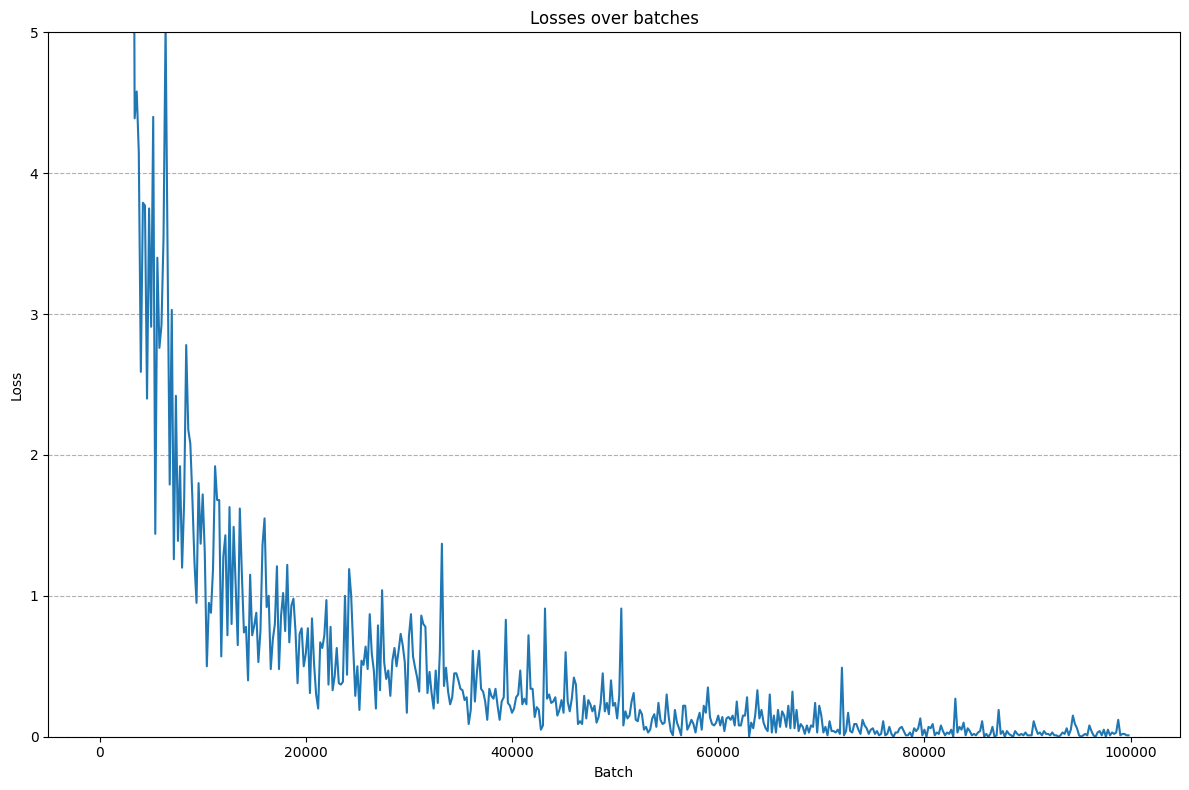

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.plot(df_train['batch'], df_train['loss'])
plt.title('Losses over batches')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.grid(axis='y', linestyle='--')
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

### Grad Norm over batches

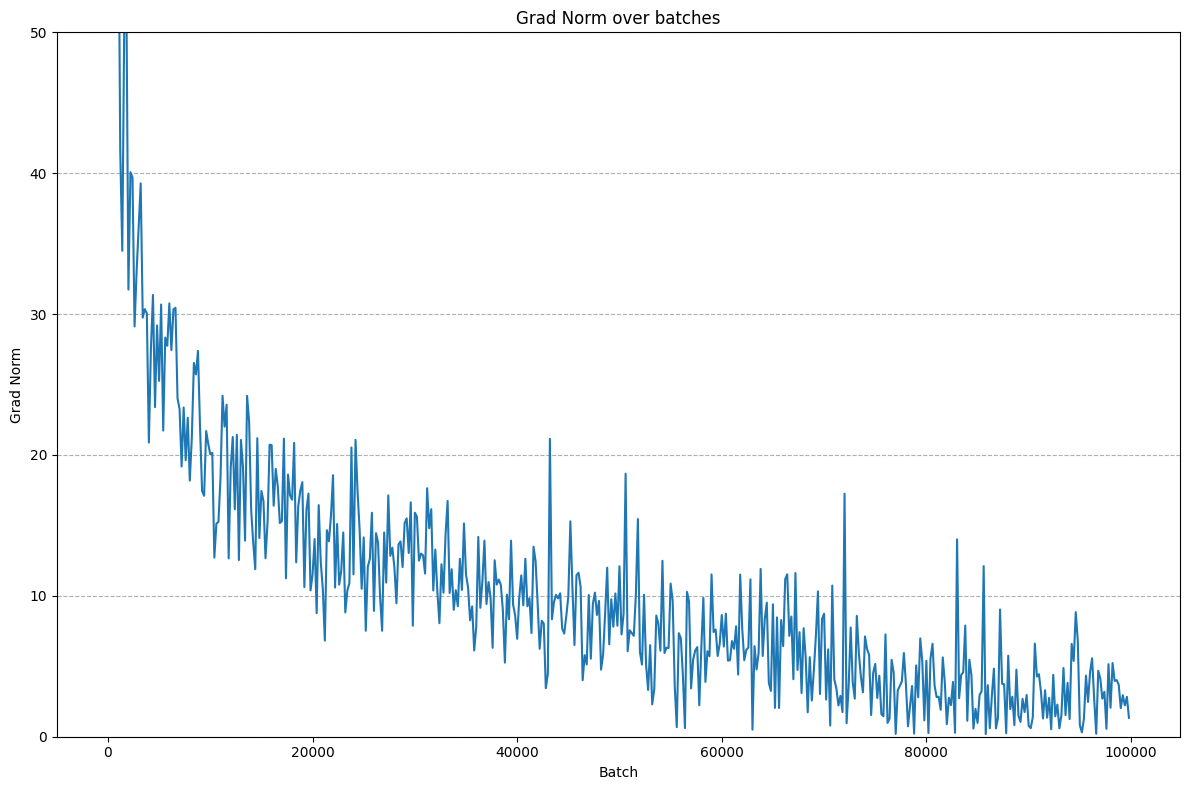

In [116]:
plt.figure(figsize=(12, 8))
plt.plot(df_train['batch'], df_train['grad_norm'])
plt.title('Grad Norm over batches')
plt.xlabel('Batch')
plt.ylabel('Grad Norm')
plt.grid(axis='y', linestyle='--')
plt.ylim(0, 50)

plt.tight_layout()
plt.show()

# Validation metrics

### PER over batches

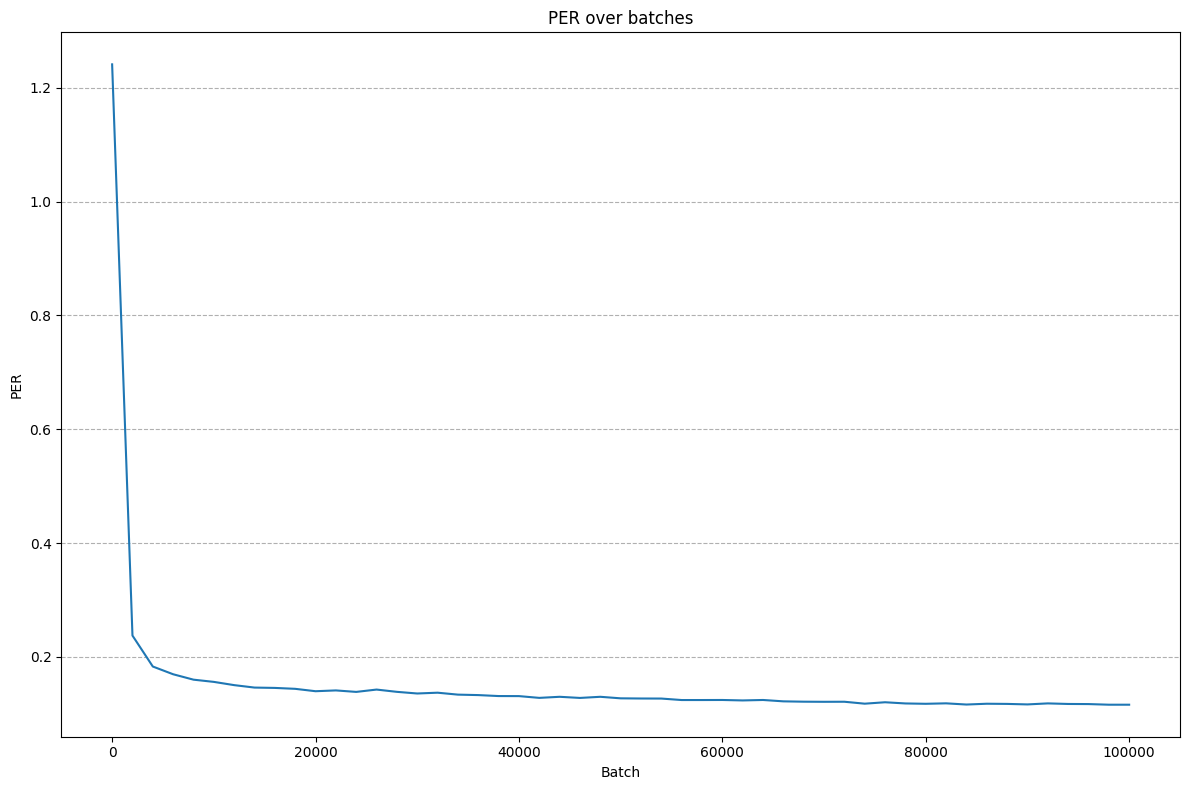

In [117]:
plt.figure(figsize=(12, 8))
plt.plot(df_val['batch'], df_val['per'])
plt.title('PER over batches')
plt.xlabel('Batch')
plt.ylabel('PER')
plt.grid(axis='y', linestyle='--')
# plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### Cross Entropy Loss over batches

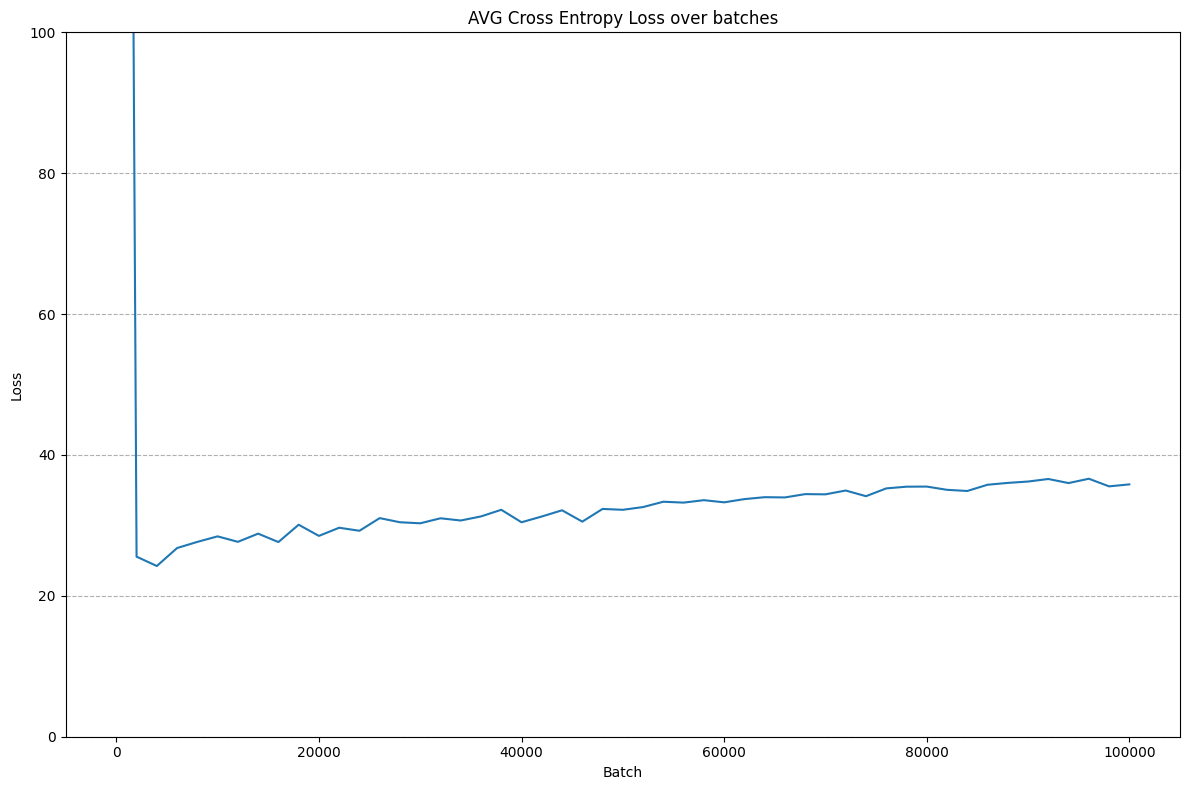

In [118]:
plt.figure(figsize=(12, 8))
plt.plot(df_val['batch'], df_val['celoss'])
plt.title('AVG Cross Entropy Loss over batches')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.grid(axis='y', linestyle='--')
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

# For AdamER_RNN

In [90]:
# I want to extract the beta custom logs and plot it
rows = []

train_pattern = re.compile(
    r'^(?P<timestamp>\S+ \S+): Train batch (?P<batch>\d+): '
    r'loss: (?P<loss>[\d.]+) grad norm: (?P<grad_norm>[\d.]+) '
    r'time: (?P<time>[\d.]+)'
)

beta_pattern = re.compile(
    r'^(?P<timestamp>\S+ \S+): CUSTOM LOG: beta - (?P<beta>[\d.]+)$'
)

train_data = []
beta_data = []

with open(TRAINING_DATA_PATH) as f:
    for line in f:
        if 'Train batch' in line:
            match = train_pattern.match(line)
            if match and int(match['batch']) % 200 == 0:
                data = match.groupdict()
                data['batch'] = int(data['batch'])
                train_data.append(data)
        elif 'CUSTOM LOG: beta' in line:
            match = beta_pattern.match(line)
            if match:
                data = match.groupdict()
                data['beta'] = float(data['beta'])
                beta_data.append(data)

df_train = pd.DataFrame(train_data)
df_beta = pd.DataFrame(beta_data).drop(columns='timestamp')
df_final = pd.concat([df_train, df_beta], axis=1)

In [91]:
df_final

,timestamp,batch,loss,grad_norm,time,beta
0,"2025-11-02 20:20:36,749",0,755.12,299.78,3.962,0.100000
1,"2025-11-02 20:22:06,382",200,93.81,14.70,0.210,0.063301
2,"2025-11-02 20:22:55,442",400,74.17,39.42,0.259,0.035944
3,"2025-11-02 20:23:44,213",600,58.98,42.79,0.170,0.022890
4,"2025-11-02 20:24:33,582",800,52.48,60.08,0.256,0.016324
...,...,...,...,...,...,...
595,"2025-11-03 04:38:11,810",119000,0.00,0.10,0.249,0.000356
596,"2025-11-03 04:39:00,208",119200,0.02,2.14,0.227,0.000356
597,"2025-11-03 04:39:49,888",119400,0.01,0.30,0.216,0.000356
598,"2025-11-03 04:40:38,689",119600,0.01,1.13,0.323,0.000356


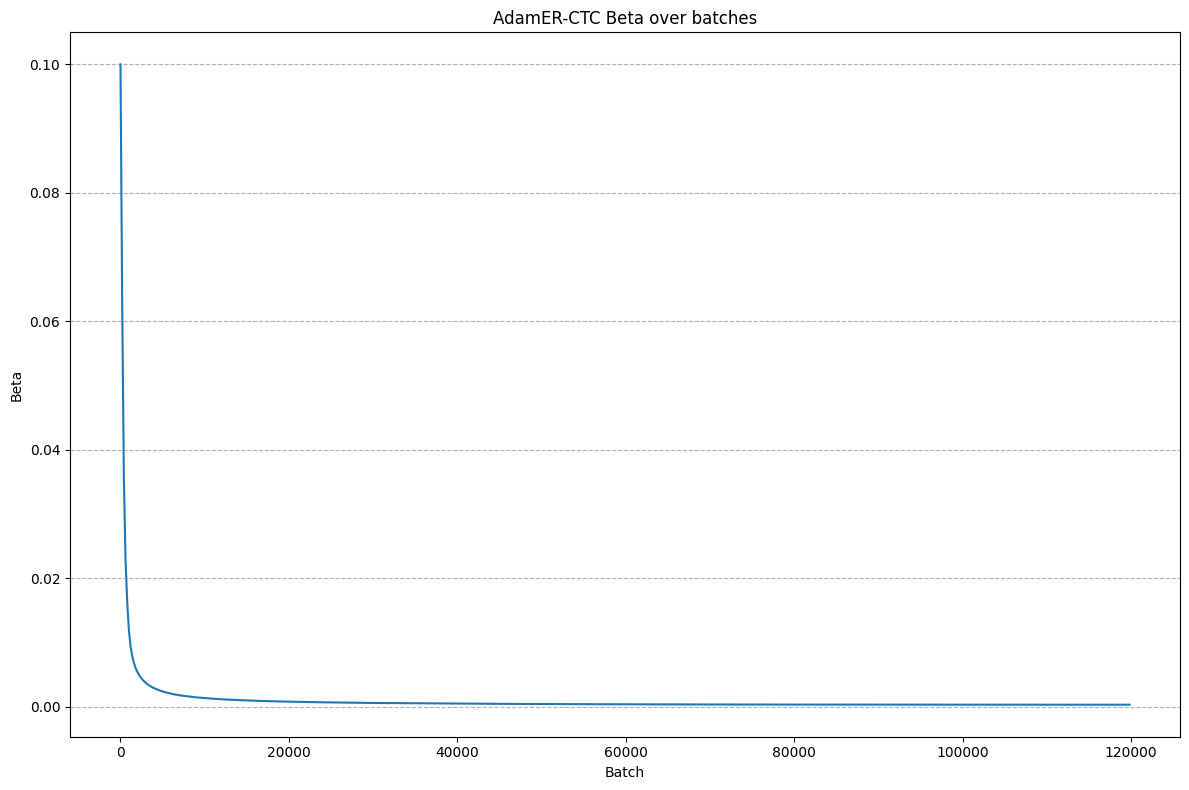

In [92]:
plt.figure(figsize=(12, 8))
plt.plot(df_final['batch'], df_final['beta'])
plt.title('AdamER-CTC Beta over batches')
plt.xlabel('Batch')
plt.ylabel('Beta')
plt.grid(axis='y', linestyle='--')
# plt.ylim(0, 0.1)

plt.tight_layout()
plt.show()